In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [5]:
# The CSV has headers: Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country
df = pd.read_csv('retail_data.csv')

C:\Users\avira\AppData\Local\Temp\ipykernel_22876\3783681296.py:2: DtypeWarning: Columns (0: Quantity, 1: Price, 2: Customer ID) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('retail_data.csv')


In [7]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

df = df.dropna(subset=['Price', 'Quantity'])

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

In [8]:
# We need the TOTAL market demand at each price point, not individual cart sizes
demand_curve = df.groupby('Price')['Quantity'].sum().reset_index()

# Optional: Remove extreme outliers (e.g., wholesale bulk orders or unique luxury items) for a cleaner curve
q_low = demand_curve['Price'].quantile(0.05)
q_hi  = demand_curve['Price'].quantile(0.95)
demand_curve = demand_curve[(demand_curve['Price'] > q_low) & (demand_curve['Price'] < q_hi)]

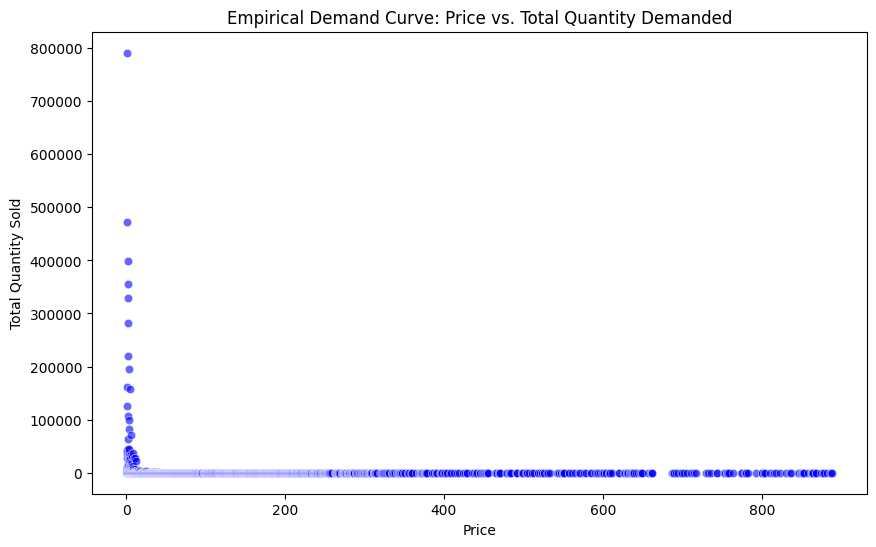

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Price', y='Quantity', data=demand_curve, alpha=0.6, color='blue')
plt.title('Empirical Demand Curve: Price vs. Total Quantity Demanded')
plt.xlabel('Price')
plt.ylabel('Total Quantity Sold')
plt.show()

In [10]:
# Log-Log transformation: \ln(D) = \ln(D_0) + \epsilon \ln(p)
demand_curve['ln_Price'] = np.log(demand_curve['Price'])
demand_curve['ln_Demand'] = np.log(demand_curve['Quantity'])

In [11]:
X = demand_curve[['ln_Price']]
y = demand_curve['ln_Demand']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
elasticity = model.coef_[0]
ln_base_demand = model.intercept_
base_demand = np.exp(ln_base_demand) # Inverse log to get actual units
r2 = r2_score(y, model.predict(X))

print(f"--- Machine Learning Model Results ---")
print(f"Model R-Squared (Fit): {r2:.2f}")
print(f"Predicted Price Elasticity (ε): {elasticity:.2f}")
print(f"Predicted Base Demand (D0): {base_demand:.0f}")

--- Machine Learning Model Results ---
Model R-Squared (Fit): 0.57
Predicted Price Elasticity (ε): -1.26
Predicted Base Demand (D0): 857
